In [1]:
!pip install skorch


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from itertools import cycle
import numpy as np
from skorch import NeuralNetClassifier
from sklearn.model_selection import GridSearchCV

In [3]:
# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

In [4]:
# Load preprocessed data
train = pd.read_csv('train_preprocessed.csv')
test = pd.read_csv('test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Encode labels
y_train_raw = train['Bias']
y_test_raw = test['Bias']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

In [5]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train['cleaned_text']).toarray()
X_test = vectorizer.transform(test['cleaned_text']).toarray()

In [6]:
# FFNN Model
class FFNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
output_dim = len(label_encoder.classes_)

In [7]:
# Wrap model for skorch
net = NeuralNetClassifier(
    FFNN,
    module__input_dim=input_dim,
    module__hidden_dim=256,
    module__output_dim=output_dim,
    max_epochs=10,
    lr=1e-3,
    optimizer=optim.Adam,
    criterion=nn.CrossEntropyLoss,
    batch_size=64,
    device=device
)


In [8]:
# Grid search parameters
param_grid = {
    'module__hidden_dim': [128, 256, 512],
    'lr': [1e-3, 5e-4],
    'batch_size': [32, 64],
    'max_epochs': [5, 10]
}

In [9]:
grid = GridSearchCV(net, param_grid, scoring='f1_macro', cv=3, verbose=1)
grid.fit(X_train.astype(np.float32), y_train)

print("Best parameters found:")
print(grid.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.5145       0.5168        1.3808  1.3520
      2        1.2872       0.5168        1.2759  0.2083
      3        1.1517       0.5168        1.2082  0.2380
      4        0.9865       0.5588        1.1261  0.2367
      5        0.7804       0.6176        1.0473  0.2374
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.5296       0.5168        1.3946  0.2186
      2        1.2854       0.5168        1.2983  0.2307
      3        1.1398       0.5168        1.2309  0.2325
      4        0.9636       0.5504        1.1505  0.2511
      5        0.7640       0.6050        1.0712  0.2225
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.5099      

In [10]:
# Evaluate best model
best_model = grid.best_estimator_
preds = best_model.predict(X_test.astype(np.float32))
probs = best_model.predict_proba(X_test.astype(np.float32))

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='macro')
report = classification_report(y_test, preds, target_names=label_encoder.classes_)

print(f"FFNN Accuracy: {acc * 100:.2f}%")
print(f"FFNN Macro F1-score: {f1:.4f}")
print("\nClassification Report:\n", report)

FFNN Accuracy: 71.69%
FFNN Macro F1-score: 0.5752

Classification Report:
               precision    recall  f1-score   support

      center       0.81      0.42      0.56        40
   lean left       0.53      0.49      0.51        61
  lean right       0.60      0.16      0.26        37
        left       0.74      0.92      0.82       230
       right       0.77      0.70      0.73        77

    accuracy                           0.72       445
   macro avg       0.69      0.54      0.58       445
weighted avg       0.71      0.72      0.69       445



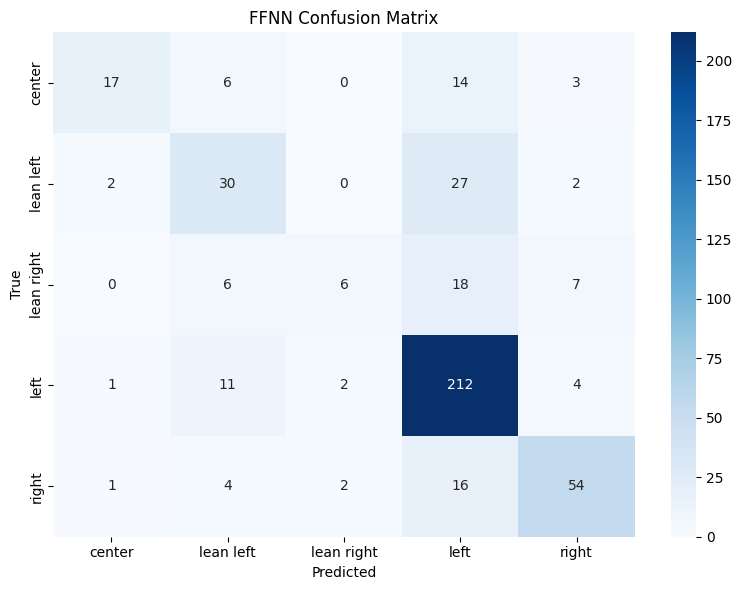

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('FFNN Confusion Matrix')
plt.tight_layout()
plt.show()


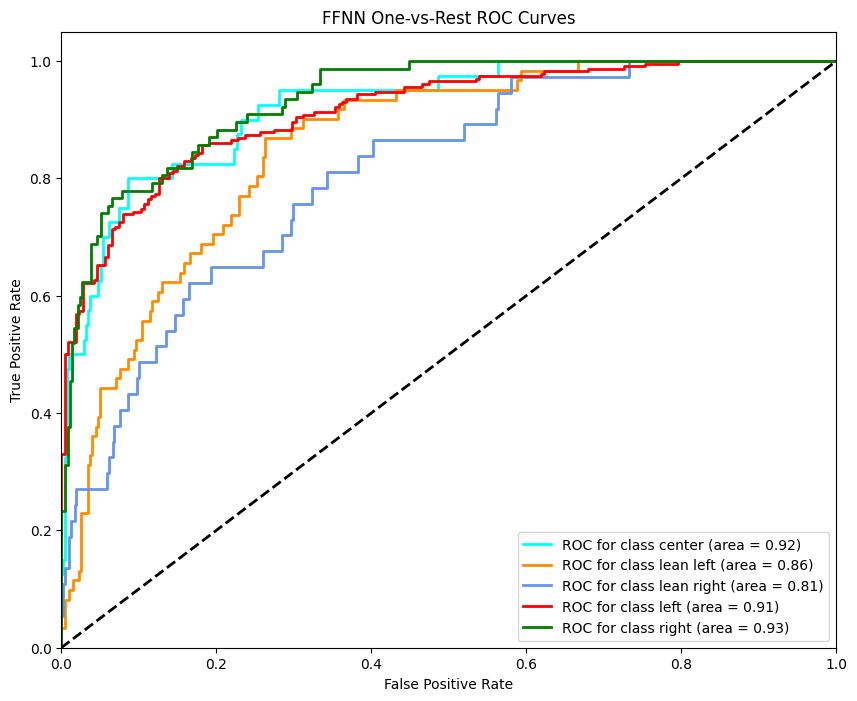

In [12]:
# ROC Curves
y_test_bin = label_binarize(y_test, classes=np.arange(output_dim))
probs = np.array(probs)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(output_dim):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc[i] = roc_auc_score(y_test_bin[:, i], probs[:, i])

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])
for i, color in zip(range(output_dim), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC for class {label_encoder.classes_[i]} (area = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('FFNN One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()
